<a href="https://colab.research.google.com/github/awatinooruddin01/Snack-Analysis_01/blob/main/Snack_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pyspark
import pyspark
print("PySpark Version:", pyspark.__version__)

PySpark Version: 4.0.2


In [2]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("PRCE002_SnackAnalysis") \
    .getOrCreate()

print("Spark is running!")
print("Spark Version:", spark.version)

Spark is running!
Spark Version: 4.0.2


In [3]:
!pip install openpyxl requests -q
import requests

files = {
    "menu.xlsx": "https://raw.githubusercontent.com/awatinooruddin01/Snack-Analysis_01/main/menu.xlsx",
    "starbucks_drinkMenu_expanded.xlsx": "https://raw.githubusercontent.com/awatinooruddin01/Snack-Analysis_01/main/starbucks_drinkMenu_expanded.xlsx",
    "starbucks-menu-nutrition-drinks.xlsx": "https://raw.githubusercontent.com/awatinooruddin01/Snack-Analysis_01/main/starbucks-menu-nutrition-drinks.xlsx",
    "starbucks-menu-nutrition-food.xlsx": "https://raw.githubusercontent.com/awatinooruddin01/Snack-Analysis_01/main/starbucks-menu-nutrition-food.xlsx",
}

for filename, url in files.items():
    response = requests.get(url)
    with open(filename, "wb") as f:
        f.write(response.content)

    size_kb = len(response.content) / 1024
    if size_kb < 5:
        print(f" {filename} — only {size_kb:.1f} KB — check your repo filename!")
    else:
        print(f" {filename} — {size_kb:.1f} KB — downloaded successfully!")

 menu.xlsx — 31.4 KB — downloaded successfully!
 starbucks_drinkMenu_expanded.xlsx — 22.2 KB — downloaded successfully!
 starbucks-menu-nutrition-drinks.xlsx — 11.0 KB — downloaded successfully!
 starbucks-menu-nutrition-food.xlsx — 9.4 KB — downloaded successfully!


In [4]:
import pandas as pd

mcdonalds_pd = pd.read_excel("menu.xlsx", sheet_name="menu.csv", engine="openpyxl")
starbucks_drinks_pd = pd.read_excel("starbucks_drinkMenu_expanded.xlsx", engine="openpyxl")
starbucks_food_pd = pd.read_excel("starbucks-menu-nutrition-food.xlsx", engine="openpyxl")

print(" McDonald's items:", mcdonalds_pd.shape)
print(" Starbucks Drinks items:", starbucks_drinks_pd.shape)
print(" Starbucks Food items:", starbucks_food_pd.shape)

 McDonald's items: (260, 24)
 Starbucks Drinks items: (242, 18)
 Starbucks Food items: (113, 6)


In [5]:
import numpy as np

def clean_dataframe(df):
    for col in df.columns:
        # Try converting each column to numeric
        converted = pd.to_numeric(df[col], errors='coerce')

        # If at least some values converted successfully, use float
        if converted.notna().sum() > 0:
            df[col] = converted.astype('float64')
        else:
            # Keep as string (text columns like item names)
            df[col] = df[col].astype(str)

    # Replace NaN with None so Spark understands empty values
    df = df.where(pd.notnull(df), None)
    return df

# Clean all 3 dataframes
mcdonalds_pd        = clean_dataframe(mcdonalds_pd)
starbucks_drinks_pd = clean_dataframe(starbucks_drinks_pd)
starbucks_food_pd   = clean_dataframe(starbucks_food_pd)

# Verify data types are consistent
print(" McDonald's dtypes:")
print(mcdonalds_pd.dtypes)

print("\n Starbucks Drinks dtypes:")
print(starbucks_drinks_pd.dtypes)

print("\n Starbucks Food dtypes:")
print(starbucks_food_pd.dtypes)


 McDonald's dtypes:
Category                          object
Item                              object
Serving Size                      object
Calories                         float64
Calories from Fat                float64
Total Fat                        float64
Total Fat (% Daily Value)        float64
Saturated Fat                    float64
Saturated Fat (% Daily Value)    float64
Trans Fat                        float64
Cholesterol                      float64
Cholesterol (% Daily Value)      float64
Sodium                           float64
Sodium (% Daily Value)           float64
Carbohydrates                    float64
Carbohydrates (% Daily Value)    float64
Dietary Fiber                    float64
Dietary Fiber (% Daily Value)    float64
Sugars                           float64
Protein                          float64
Vitamin A (% Daily Value)        float64
Vitamin C (% Daily Value)        float64
Calcium (% Daily Value)          float64
Iron (% Daily Value)             floa

In [6]:
# Convert to PySpark DataFrames
mcdonalds_df        = spark.createDataFrame(mcdonalds_pd)
starbucks_drinks_df = spark.createDataFrame(starbucks_drinks_pd)
starbucks_food_df   = spark.createDataFrame(starbucks_food_pd)

print(" McDonald's Spark DataFrame ready!    Rows:", mcdonalds_df.count())
print(" Starbucks Drinks Spark DataFrame ready! Rows:", starbucks_drinks_df.count())
print(" Starbucks Food Spark DataFrame ready!   Rows:", starbucks_food_df.count())

 McDonald's Spark DataFrame ready!    Rows: 260
 Starbucks Drinks Spark DataFrame ready! Rows: 242
 Starbucks Food Spark DataFrame ready!   Rows: 113


In [7]:
# See first 5 rows of each dataset
print("=" * 50)
print("McDONALD'S — First 5 rows:")
print("=" * 50)
mcdonalds_df.show(5, truncate=True)

print("=" * 50)
print("STARBUCKS DRINKS — First 5 rows:")
print("=" * 50)
starbucks_drinks_df.show(5, truncate=True)

print("=" * 50)
print("STARBUCKS FOOD — First 5 rows:")
print("=" * 50)
starbucks_food_df.show(5, truncate=True)

McDONALD'S — First 5 rows:
+---------+--------------------+--------------+--------+-----------------+---------+-------------------------+-------------+-----------------------------+---------+-----------+---------------------------+------+----------------------+-------------+-----------------------------+-------------+-----------------------------+------+-------+-------------------------+-------------------------+-----------------------+--------------------+
| Category|                Item|  Serving Size|Calories|Calories from Fat|Total Fat|Total Fat (% Daily Value)|Saturated Fat|Saturated Fat (% Daily Value)|Trans Fat|Cholesterol|Cholesterol (% Daily Value)|Sodium|Sodium (% Daily Value)|Carbohydrates|Carbohydrates (% Daily Value)|Dietary Fiber|Dietary Fiber (% Daily Value)|Sugars|Protein|Vitamin A (% Daily Value)|Vitamin C (% Daily Value)|Calcium (% Daily Value)|Iron (% Daily Value)|
+---------+--------------------+--------------+--------+-----------------+---------+-------------------

In [8]:
#check column names
print("McDONALD'S columns:")
print(mcdonalds_df.columns)

print("\nSTARBUCKS DRINKS columns:")
print(starbucks_drinks_df.columns)

print("\nSTARBUCKS FOOD columns:")
print(starbucks_food_df.columns)

McDONALD'S columns:
['Category', 'Item', 'Serving Size', 'Calories', 'Calories from Fat', 'Total Fat', 'Total Fat (% Daily Value)', 'Saturated Fat', 'Saturated Fat (% Daily Value)', 'Trans Fat', 'Cholesterol', 'Cholesterol (% Daily Value)', 'Sodium', 'Sodium (% Daily Value)', 'Carbohydrates', 'Carbohydrates (% Daily Value)', 'Dietary Fiber', 'Dietary Fiber (% Daily Value)', 'Sugars', 'Protein', 'Vitamin A (% Daily Value)', 'Vitamin C (% Daily Value)', 'Calcium (% Daily Value)', 'Iron (% Daily Value)']

STARBUCKS DRINKS columns:
['Beverage_category', 'Beverage', 'Beverage_prep', 'Calories', 'Total Fat (g)', 'Trans Fat (g)', 'Saturated Fat (g)', 'Sodium (mg)', 'Total Carbohydrates (g)', 'Cholesterol (mg)', 'Dietary Fibre (g)', 'Sugars (g)', 'Protein (g)', 'Vitamin A (% DV)', 'Vitamin C (% DV)', 'Calcium (% DV)', 'Iron (% DV)', 'Caffeine (mg)']

STARBUCKS FOOD columns:
['Unnamed: 0', 'Calories', 'Fat (g)', 'Carb. (g)', 'Fiber (g)', 'Protein (g)']


In [9]:
# ── Rename columns to clean simple names ──────────────────────────

# McDonald's
mcdonalds_df = mcdonalds_df.toDF(
    "Category", "Item", "Serving_Size", "Calories", "Calories_from_Fat",
    "Total_Fat", "Total_Fat_DV", "Saturated_Fat", "Saturated_Fat_DV",
    "Trans_Fat", "Cholesterol", "Cholesterol_DV", "Sodium", "Sodium_DV",
    "Carbohydrates", "Carbohydrates_DV", "Dietary_Fiber", "Dietary_Fiber_DV",
    "Sugars", "Protein", "Vitamin_A", "Vitamin_C", "Calcium", "Iron"
)

# Starbucks Drinks
starbucks_drinks_df = starbucks_drinks_df.toDF(
    "Category", "Beverage", "Prep", "Calories", "Total_Fat", "Trans_Fat",
    "Saturated_Fat", "Sodium", "Carbohydrates", "Cholesterol",
    "Dietary_Fiber", "Sugars", "Protein", "Vitamin_A", "Vitamin_C",
    "Calcium", "Iron", "Caffeine"
)

# Starbucks Food
starbucks_food_df = starbucks_food_df.toDF(
    "Item", "Calories", "Fat", "Carbohydrates", "Dietary_Fiber", "Protein"
)

print(" McDonald's columns renamed:")
print(mcdonalds_df.columns)

print("\n Starbucks Drinks columns renamed:")
print(starbucks_drinks_df.columns)

print("\n Starbucks Food columns renamed:")
print(starbucks_food_df.columns)

 McDonald's columns renamed:
['Category', 'Item', 'Serving_Size', 'Calories', 'Calories_from_Fat', 'Total_Fat', 'Total_Fat_DV', 'Saturated_Fat', 'Saturated_Fat_DV', 'Trans_Fat', 'Cholesterol', 'Cholesterol_DV', 'Sodium', 'Sodium_DV', 'Carbohydrates', 'Carbohydrates_DV', 'Dietary_Fiber', 'Dietary_Fiber_DV', 'Sugars', 'Protein', 'Vitamin_A', 'Vitamin_C', 'Calcium', 'Iron']

 Starbucks Drinks columns renamed:
['Category', 'Beverage', 'Prep', 'Calories', 'Total_Fat', 'Trans_Fat', 'Saturated_Fat', 'Sodium', 'Carbohydrates', 'Cholesterol', 'Dietary_Fiber', 'Sugars', 'Protein', 'Vitamin_A', 'Vitamin_C', 'Calcium', 'Iron', 'Caffeine']

 Starbucks Food columns renamed:
['Item', 'Calories', 'Fat', 'Carbohydrates', 'Dietary_Fiber', 'Protein']


In [10]:
#check for missing values
from pyspark.sql.functions import col, count, when, isnan

def check_missing(df, name):
    print(f"\n{'='*50}")
    print(f"MISSING VALUES — {name}")
    print(f"{'='*50}")
    missing = df.select([
        count(when(col(c).isNull(), c)).alias(c)
        for c in df.columns
    ])
    missing.show(truncate=False)

check_missing(mcdonalds_df, "McDonald's")
check_missing(starbucks_drinks_df, "Starbucks Drinks")
check_missing(starbucks_food_df, "Starbucks Food")


MISSING VALUES — McDonald's
+--------+----+------------+--------+-----------------+---------+------------+-------------+----------------+---------+-----------+--------------+------+---------+-------------+----------------+-------------+----------------+------+-------+---------+---------+-------+----+
|Category|Item|Serving_Size|Calories|Calories_from_Fat|Total_Fat|Total_Fat_DV|Saturated_Fat|Saturated_Fat_DV|Trans_Fat|Cholesterol|Cholesterol_DV|Sodium|Sodium_DV|Carbohydrates|Carbohydrates_DV|Dietary_Fiber|Dietary_Fiber_DV|Sugars|Protein|Vitamin_A|Vitamin_C|Calcium|Iron|
+--------+----+------------+--------+-----------------+---------+------------+-------------+----------------+---------+-----------+--------------+------+---------+-------------+----------------+-------------+----------------+------+-------+---------+---------+-------+----+
|0       |0   |0           |0       |0                |0        |0           |0            |0               |0        |0          |0             |0  

In [11]:
from pyspark.sql.functions import avg, round

print("=" * 50)
print("AVERAGE CALORIES COMPARISON")
print("=" * 50)

# McDonald's average calories
print("\nMcDonald's — Avg Calories per item:")
mcdonalds_df.select(round(avg("Calories"), 2).alias("Avg_Calories")).show()

# Starbucks Drinks average calories
print("Starbucks Drinks — Avg Calories per item:")
starbucks_drinks_df.select(round(avg("Calories"), 2).alias("Avg_Calories")).show()

# Starbucks Food average calories
print("Starbucks Food — Avg Calories per item:")
starbucks_food_df.select(round(avg("Calories"), 2).alias("Avg_Calories")).show()

AVERAGE CALORIES COMPARISON

McDonald's — Avg Calories per item:
+------------+
|Avg_Calories|
+------------+
|      368.27|
+------------+

Starbucks Drinks — Avg Calories per item:
+------------+
|Avg_Calories|
+------------+
|      193.87|
+------------+

Starbucks Food — Avg Calories per item:
+------------+
|Avg_Calories|
+------------+
|      356.64|
+------------+



In [12]:
#Avg Nutrition
print("=" * 50)
print("McDONALD'S — Avg Nutrition")
print("=" * 50)
mcdonalds_df.select(
    round(avg("Total_Fat"), 2).alias("Avg_Total_Fat"),
    round(avg("Saturated_Fat"), 2).alias("Avg_Saturated_Fat"),
    round(avg("Sugars"), 2).alias("Avg_Sugars"),
    round(avg("Protein"), 2).alias("Avg_Protein"),
    round(avg("Dietary_Fiber"), 2).alias("Avg_Fiber"),
    round(avg("Sodium"), 2).alias("Avg_Sodium"),
    round(avg("Cholesterol"), 2).alias("Avg_Cholesterol")
).show()

print("=" * 50)
print("STARBUCKS DRINKS — Avg Nutrition")
print("=" * 50)
starbucks_drinks_df.select(
    round(avg("Total_Fat"), 2).alias("Avg_Total_Fat"),
    round(avg("Saturated_Fat"), 2).alias("Avg_Saturated_Fat"),
    round(avg("Sugars"), 2).alias("Avg_Sugars"),
    round(avg("Protein"), 2).alias("Avg_Protein"),
    round(avg("Dietary_Fiber"), 2).alias("Avg_Fiber"),
    round(avg("Sodium"), 2).alias("Avg_Sodium"),
    round(avg("Cholesterol"), 2).alias("Avg_Cholesterol")
).show()

print("=" * 50)
print("STARBUCKS FOOD — Avg Nutrition")
print("=" * 50)
starbucks_food_df.select(
    round(avg("Fat"), 2).alias("Avg_Total_Fat"),
    round(avg("Carbohydrates"), 2).alias("Avg_Carbs"),
    round(avg("Protein"), 2).alias("Avg_Protein"),
    round(avg("Dietary_Fiber"), 2).alias("Avg_Fiber")
).show()

McDONALD'S — Avg Nutrition
+-------------+-----------------+----------+-----------+---------+----------+---------------+
|Avg_Total_Fat|Avg_Saturated_Fat|Avg_Sugars|Avg_Protein|Avg_Fiber|Avg_Sodium|Avg_Cholesterol|
+-------------+-----------------+----------+-----------+---------+----------+---------------+
|        14.17|             6.01|     29.42|      13.34|     1.63|    495.75|          54.94|
+-------------+-----------------+----------+-----------+---------+----------+---------------+

STARBUCKS DRINKS — Avg Nutrition
+-------------+-----------------+----------+-----------+---------+----------+---------------+
|Avg_Total_Fat|Avg_Saturated_Fat|Avg_Sugars|Avg_Protein|Avg_Fiber|Avg_Sodium|Avg_Cholesterol|
+-------------+-----------------+----------+-----------+---------+----------+---------------+
|          NaN|             0.04|     32.96|       6.98|     0.81|      6.36|          35.99|
+-------------+-----------------+----------+-----------+---------+----------+---------------+

In [13]:
#Avg Calories by Category
print("=" * 50)
print("McDONALD'S — Avg Calories by Category")
print("=" * 50)
mcdonalds_df.groupBy("Category") \
    .agg(round(avg("Calories"), 2).alias("Avg_Calories")) \
    .orderBy("Avg_Calories", ascending=False) \
    .show(truncate=False)

print("=" * 50)
print("STARBUCKS — Avg Calories by Drink Category")
print("=" * 50)
starbucks_drinks_df.groupBy("Category") \
    .agg(round(avg("Calories"), 2).alias("Avg_Calories")) \
    .orderBy("Avg_Calories", ascending=False) \
    .show(truncate=False)

McDONALD'S — Avg Calories by Category
+------------------+------------+
|Category          |Avg_Calories|
+------------------+------------+
|Chicken & Fish    |552.96      |
|Smoothies & Shakes|531.43      |
|Breakfast         |526.67      |
|Beef & Pork       |494.0       |
|Coffee & Tea      |283.89      |
|Salads            |270.0       |
|Snacks & Sides    |245.77      |
|Desserts          |222.14      |
|Beverages         |113.7       |
+------------------+------------+

STARBUCKS — Avg Calories by Drink Category
+---------------------------------+------------+
|Category                         |Avg_Calories|
+---------------------------------+------------+
|Smoothies                        |282.22      |
|Frappuccino® Blended Coffee      |276.94      |
|Signature Espresso Drinks        |250.0       |
|Frappuccino® Blended Crème       |233.08      |
|Tazo® Tea Drinks                 |177.31      |
|Frappuccino® Light Blended Coffee|162.5       |
|Classic Espresso Drinks          |

In [14]:
#HIGHEST CALORIE
print("=" * 50)
print("TOP 5 HIGHEST CALORIE — McDonald's")
print("=" * 50)
mcdonalds_df.select("Category", "Item", "Calories") \
    .orderBy("Calories", ascending=False) \
    .show(5, truncate=False)

print("=" * 50)
print("TOP 5 HIGHEST CALORIE — Starbucks Drinks")
print("=" * 50)
starbucks_drinks_df.select("Category", "Beverage", "Prep", "Calories") \
    .orderBy("Calories", ascending=False) \
    .show(5, truncate=False)

print("=" * 50)
print("TOP 5 HIGHEST CALORIE — Starbucks Food")
print("=" * 50)
starbucks_food_df.select("Item", "Calories", "Fat", "Protein") \
    .orderBy("Calories", ascending=False) \
    .show(5, truncate=False)

TOP 5 HIGHEST CALORIE — McDonald's
+--------------+------------------------------------------------------------+--------+
|Category      |Item                                                        |Calories|
+--------------+------------------------------------------------------------+--------+
|Chicken & Fish|Chicken McNuggets (40 piece)                                |1880.0  |
|Breakfast     |Big Breakfast with Hotcakes (Large Biscuit)                 |1150.0  |
|Breakfast     |Big Breakfast with Hotcakes (Regular Biscuit)               |1090.0  |
|Breakfast     |Big Breakfast with Hotcakes and Egg Whites (Large Biscuit)  |1050.0  |
|Breakfast     |Big Breakfast with Hotcakes and Egg Whites (Regular Biscuit)|990.0   |
+--------------+------------------------------------------------------------+--------+
only showing top 5 rows
TOP 5 HIGHEST CALORIE — Starbucks Drinks
+---------------------------+---------------------------------------------+-----------------+--------+
|Category     

In [15]:
#LOW CALORIE OPTIONS
# Used Python's built-in round explicitly to avoid PySpark conflict
import builtins

print("=" * 50)
print("LOW CALORIE OPTIONS (Under 200 calories)")
print("=" * 50)

mcd_low       = mcdonalds_df.filter(mcdonalds_df["Calories"] < 200).count()
sb_drinks_low = starbucks_drinks_df.filter(starbucks_drinks_df["Calories"] < 200).count()
sb_food_low   = starbucks_food_df.filter(starbucks_food_df["Calories"] < 200).count()

mcd_total       = mcdonalds_df.count()
sb_drinks_total = starbucks_drinks_df.count()
sb_food_total   = starbucks_food_df.count()

mcd_pct      = builtins.round((mcd_low / mcd_total) * 100, 1)
sb_drink_pct = builtins.round((sb_drinks_low / sb_drinks_total) * 100, 1)
sb_food_pct  = builtins.round((sb_food_low / sb_food_total) * 100, 1)

print(f"\nMcDonald's:       {mcd_low} out of {mcd_total} items ({mcd_pct}%)")
print(f"Starbucks Drinks: {sb_drinks_low} out of {sb_drinks_total} items ({sb_drink_pct}%)")
print(f"Starbucks Food:   {sb_food_low} out of {sb_food_total} items ({sb_food_pct}%)")

LOW CALORIE OPTIONS (Under 200 calories)

McDonald's:       60 out of 260 items (23.1%)
Starbucks Drinks: 132 out of 242 items (54.5%)
Starbucks Food:   17 out of 113 items (15.0%)


In [16]:
# high protein options
import builtins

print("=" * 50)
print("HIGH PROTEIN OPTIONS (Above 20g protein)")
print("=" * 50)

mcd_protein      = mcdonalds_df.filter(mcdonalds_df["Protein"] > 20).count()
sb_drinks_protein = starbucks_drinks_df.filter(starbucks_drinks_df["Protein"] > 20).count()
sb_food_protein   = starbucks_food_df.filter(starbucks_food_df["Protein"] > 20).count()

mcd_pct      = builtins.round((mcd_protein / mcd_total) * 100, 1)
sb_drink_pct = builtins.round((sb_drinks_protein / sb_drinks_total) * 100, 1)
sb_food_pct  = builtins.round((sb_food_protein / sb_food_total) * 100, 1)

print(f"\nMcDonald's:       {mcd_protein} out of {mcd_total} items ({mcd_pct}%)")
print(f"Starbucks Drinks: {sb_drinks_protein} out of {sb_drinks_total} items ({sb_drink_pct}%)")
print(f"Starbucks Food:   {sb_food_protein} out of {sb_food_total} items ({sb_food_pct}%)")

HIGH PROTEIN OPTIONS (Above 20g protein)

McDonald's:       55 out of 260 items (21.2%)
Starbucks Drinks: 0 out of 242 items (0.0%)
Starbucks Food:   23 out of 113 items (20.4%)


In [17]:
#FINAL HEALTH COMPARISON SUMMARY
print("=" * 60)
print("       FINAL HEALTH COMPARISON SUMMARY")
print("=" * 60)

print("""
METRIC                  McDONALD'S    STARBUCKS     WINNER
──────────────────────────────────────────────────────────
Avg Calories            368.3         193.9 (drinks) Starbucks
Avg Total Fat (g)       14.2          2.9   (drinks) Starbucks
Avg Saturated Fat (g)   6.0           0.0   (drinks) Starbucks
Avg Sodium (mg)         495.8         6.4   (drinks) Starbucks
Avg Sugars (g)          29.4          33.0  (drinks) McDonald's
Avg Protein (g)         13.3          7.0   (drinks) McDonald's
Avg Dietary Fiber (g)   1.6           2.8   (food)   Starbucks
Low Calorie Items       23.1%         54.5% (drinks) Starbucks
High Protein Items      21.2%         0.0%  (drinks) McDonald's
──────────────────────────────────────────────────────────
OVERALL WINNER: STARBUCKS (healthier in 6 out of 9 metrics)
""")

       FINAL HEALTH COMPARISON SUMMARY

METRIC                  McDONALD'S    STARBUCKS     WINNER
──────────────────────────────────────────────────────────
Avg Calories            368.3         193.9 (drinks) Starbucks
Avg Total Fat (g)       14.2          2.9   (drinks) Starbucks
Avg Saturated Fat (g)   6.0           0.0   (drinks) Starbucks
Avg Sodium (mg)         495.8         6.4   (drinks) Starbucks
Avg Sugars (g)          29.4          33.0  (drinks) McDonald's
Avg Protein (g)         13.3          7.0   (drinks) McDonald's
Avg Dietary Fiber (g)   1.6           2.8   (food)   Starbucks
Low Calorie Items       23.1%         54.5% (drinks) Starbucks
High Protein Items      21.2%         0.0%  (drinks) McDonald's
──────────────────────────────────────────────────────────
OVERALL WINNER: STARBUCKS (healthier in 6 out of 9 metrics)



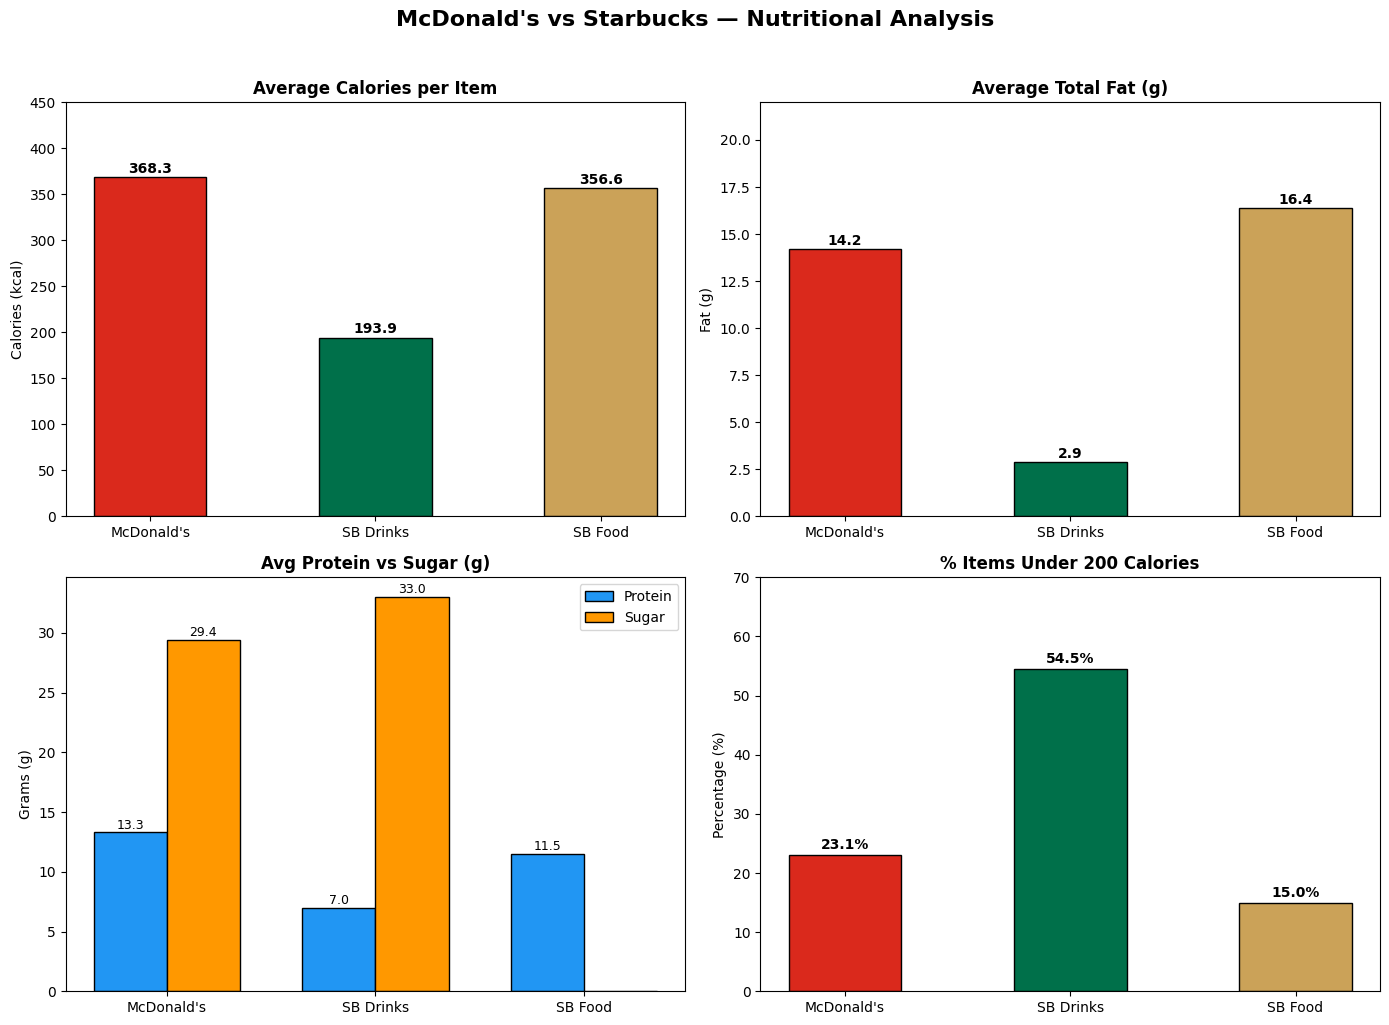

 Chart saved as nutrition_comparison.png


In [18]:
# Visualization
import matplotlib.pyplot as plt
import numpy as np

# ── Chart 1: Average Calories Comparison ──────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("McDonald's vs Starbucks — Nutritional Analysis",
             fontsize=16, fontweight='bold', y=1.02)

# Data
brands       = ["McDonald's", "SB Drinks", "SB Food"]
colors_main  = ["#DA291C", "#00704A", "#CBA258"]

# -- Chart 1: Avg Calories --
calories = [368.3, 193.9, 356.6]
axes[0, 0].bar(brands, calories, color=colors_main, edgecolor='black', width=0.5)
axes[0, 0].set_title("Average Calories per Item", fontweight='bold')
axes[0, 0].set_ylabel("Calories (kcal)")
for i, v in enumerate(calories):
    axes[0, 0].text(i, v + 5, str(v), ha='center', fontweight='bold')
axes[0, 0].set_ylim(0, 450)

# -- Chart 2: Avg Fat --
fat = [14.2, 2.9, 16.4]
axes[0, 1].bar(brands, fat, color=colors_main, edgecolor='black', width=0.5)
axes[0, 1].set_title("Average Total Fat (g)", fontweight='bold')
axes[0, 1].set_ylabel("Fat (g)")
for i, v in enumerate(fat):
    axes[0, 1].text(i, v + 0.2, str(v), ha='center', fontweight='bold')
axes[0, 1].set_ylim(0, 22)

# -- Chart 3: Avg Protein vs Sugar --
x      = np.arange(len(brands))
width  = 0.35
protein = [13.3, 7.0, 11.5]
sugar   = [29.4, 33.0, 0]

bars1 = axes[1, 0].bar(x - width/2, protein, width,
                        label='Protein', color='#2196F3', edgecolor='black')
bars2 = axes[1, 0].bar(x + width/2, sugar, width,
                        label='Sugar', color='#FF9800', edgecolor='black')
axes[1, 0].set_title("Avg Protein vs Sugar (g)", fontweight='bold')
axes[1, 0].set_ylabel("Grams (g)")
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(brands)
axes[1, 0].legend()
for bar in bars1:
    axes[1, 0].text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.3,
                    str(bar.get_height()), ha='center', fontsize=9)
for bar in bars2:
    if bar.get_height() > 0:
        axes[1, 0].text(bar.get_x() + bar.get_width()/2,
                        bar.get_height() + 0.3,
                        str(bar.get_height()), ha='center', fontsize=9)

# -- Chart 4: Low Calorie % --
low_cal_pct = [23.1, 54.5, 15.0]
bar_colors  = ["#DA291C", "#00704A", "#CBA258"]
bars = axes[1, 1].bar(brands, low_cal_pct,
                       color=bar_colors, edgecolor='black', width=0.5)
axes[1, 1].set_title("% Items Under 200 Calories", fontweight='bold')
axes[1, 1].set_ylabel("Percentage (%)")
axes[1, 1].set_ylim(0, 70)
for i, v in enumerate(low_cal_pct):
    axes[1, 1].text(i, v + 1, f"{v}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig("nutrition_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Chart saved as nutrition_comparison.png")

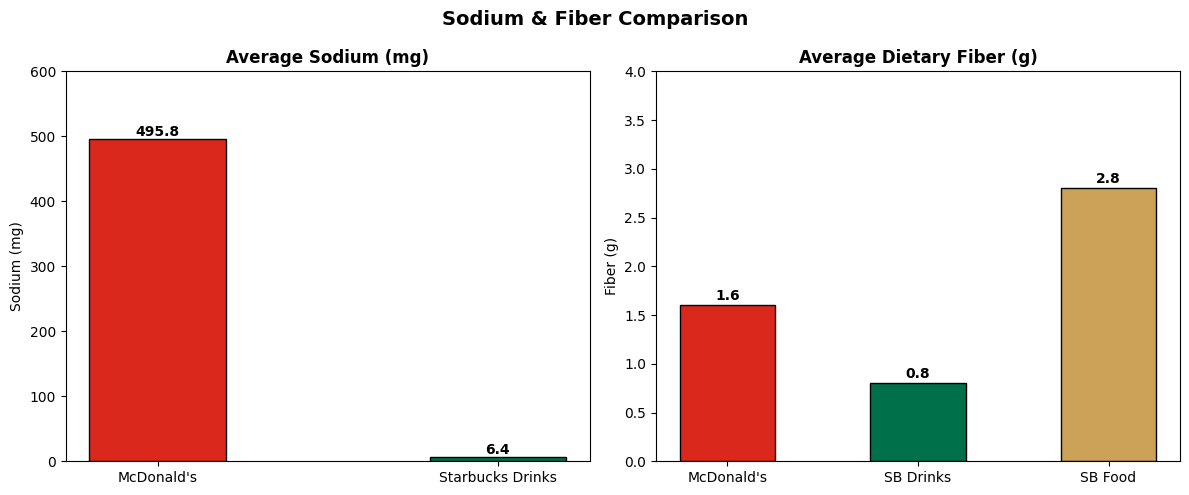

 Chart saved as sodium_fiber_comparison.png


In [19]:
#sodium vs fiber
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Sodium & Fiber Comparison", fontsize=14, fontweight='bold')

# -- Chart 5: Sodium --
sodium  = [495.8, 6.4]
brands2 = ["McDonald's", "Starbucks Drinks"]
colors2 = ["#DA291C", "#00704A"]

axes[0].bar(brands2, sodium, color=colors2, edgecolor='black', width=0.4)
axes[0].set_title("Average Sodium (mg)", fontweight='bold')
axes[0].set_ylabel("Sodium (mg)")
axes[0].set_ylim(0, 600)
for i, v in enumerate(sodium):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# -- Chart 6: Dietary Fiber --
fiber   = [1.6, 0.8, 2.8]
axes[1].bar(brands, fiber, color=colors_main, edgecolor='black', width=0.5)
axes[1].set_title("Average Dietary Fiber (g)", fontweight='bold')
axes[1].set_ylabel("Fiber (g)")
axes[1].set_ylim(0, 4)
for i, v in enumerate(fiber):
    axes[1].text(i, v + 0.05, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig("sodium_fiber_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Chart saved as sodium_fiber_comparison.png")

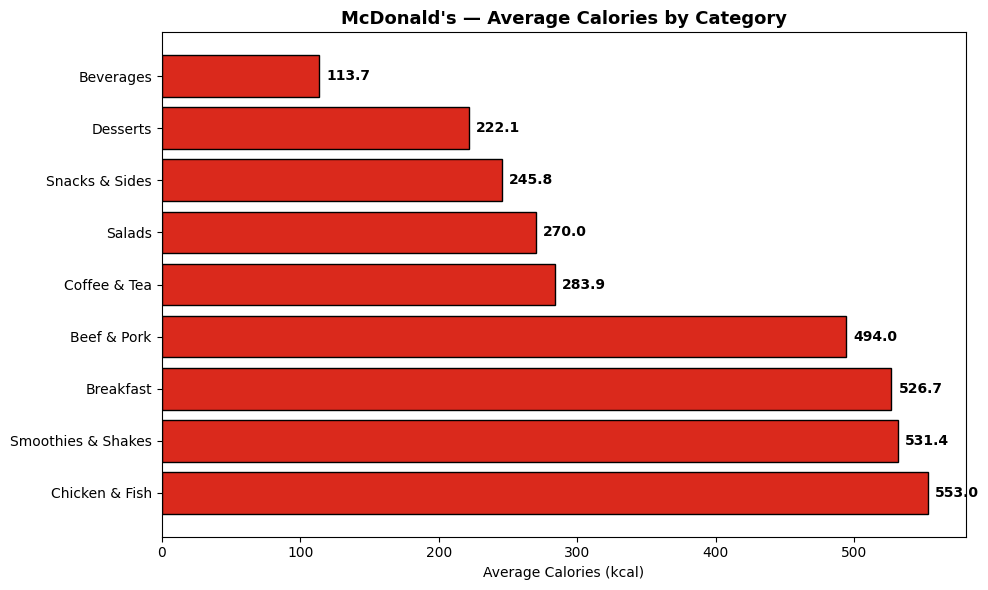

 Chart saved as mcdonalds_categories.png


In [20]:
#mcd avg calory
from pyspark.sql.functions import avg, round as spark_round

category_data = mcdonalds_df.groupBy("Category") \
    .agg(spark_round(avg("Calories"), 1).alias("Avg_Calories")) \
    .orderBy("Avg_Calories", ascending=False) \
    .toPandas()

plt.figure(figsize=(10, 6))
bars = plt.barh(category_data["Category"],
                category_data["Avg_Calories"],
                color="#DA291C", edgecolor='black')
plt.title("McDonald's — Average Calories by Category",
          fontsize=13, fontweight='bold')
plt.xlabel("Average Calories (kcal)")
for bar, val in zip(bars, category_data["Avg_Calories"]):
    plt.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontweight='bold')
plt.tight_layout()
plt.savefig("mcdonalds_categories.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Chart saved as mcdonalds_categories.png")

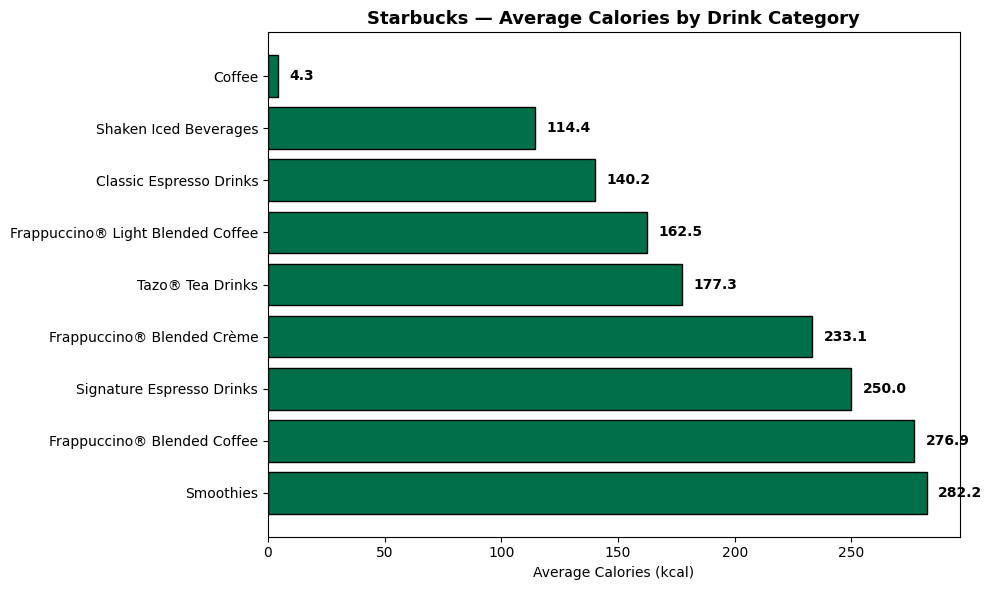

 Chart saved as starbucks_categories.png


In [21]:
#starbucks drinks avg calories
sb_category_data = starbucks_drinks_df.groupBy("Category") \
    .agg(spark_round(avg("Calories"), 1).alias("Avg_Calories")) \
    .orderBy("Avg_Calories", ascending=False) \
    .toPandas()

plt.figure(figsize=(10, 6))
bars = plt.barh(sb_category_data["Category"],
                sb_category_data["Avg_Calories"],
                color="#00704A", edgecolor='black')
plt.title("Starbucks — Average Calories by Drink Category",
          fontsize=13, fontweight='bold')
plt.xlabel("Average Calories (kcal)")
for bar, val in zip(bars, sb_category_data["Avg_Calories"]):
    plt.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontweight='bold')
plt.tight_layout()
plt.savefig("starbucks_categories.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Chart saved as starbucks_categories.png")